# Etapa 4 — Otimização e Tuning de Hiperparâmetros

**Modelo base:** Regressão Linear (será otimizado usando Ridge — versão regularizada da regressão linear).  

**Target:** `views` (conforme informado).  



In [1]:

# %%
# Imports
import os
import joblib
import pickle
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import json


In [2]:

# %%
# (2) Carregar dados
csv_path = "/content/students_clean.csv"   # arquivo que você enviou
scaler_path = "/content/scaler.pkl"        # scaler que você enviou

df = pd.read_csv(csv_path)
print("Shape:", df.shape)
display(df.head())

# Confirmar que target 'views' existe
target_col = "total_views"
if target_col not in df.columns:
    raise ValueError(f"Coluna alvo '{target_col}' não encontrada. Colunas disponíveis:\n{df.columns.tolist()}")


Shape: (2520, 46)


,duration_minutes,title_length,description_length,tags_count,channel_subscribers,channel_age_months,previous_videos_count,avg_upload_frequency_days,comments_count,likes_count,...,has_subtitles_Sim,promoted_Sim,upload_time_Manhã,upload_time_Noite,upload_time_Tarde,upload_day_Seg-Qui,upload_day_Sexta,upload_day_Sábado,likes_per_share,subs_per_month
0,-1.637160,-0.054999,0.193606,0.637127,-1.634891,-0.012753,1.087937,-0.769581,-0.736755,-1.357659,...,-0.840334,-0.422696,-0.609756,-0.578572,1.802659,-0.552289,1.724750,-0.580405,-0.019925,-0.384847
1,1.611535,1.553480,-0.003821,-0.528060,1.310451,-0.012753,-1.519924,-0.196286,1.678099,-1.072161,...,-0.840334,2.365768,-0.609756,-0.578572,1.802659,-0.552289,1.724750,-0.580405,-0.019925,-0.103013
2,0.870605,-0.744347,-1.345596,-0.322439,0.857983,-0.012753,-1.287201,-1.686854,0.726654,0.607079,...,-0.840334,-0.422696,1.640001,-0.578572,-0.554736,1.810646,-0.579794,-0.580405,-0.019924,-0.146309
3,-1.352187,-1.625180,-1.009239,-1.419086,-1.131289,0.708441,-1.054479,-0.654922,1.604911,1.199186,...,1.190003,-0.422696,-0.609756,-0.578572,-0.554736,-0.552289,-0.579794,1.722935,-0.019925,-0.351044
4,1.383556,1.515183,0.409314,1.596692,1.125262,-1.541684,-0.287864,-0.310945,-0.669931,1.067060,...,-0.840334,-0.422696,1.640001,-0.578572,-0.554736,-0.552289,-0.579794,-0.580405,-0.019923,2.213580


In [3]:

# %%
# (3) Preparar X e y; split em treino+val e teste
X = df.drop(columns=[target_col])
y = df[target_col]

# separar teste (15%) que será usado apenas UMA VEZ no final
X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

print("Treino+Val:", X_trainval.shape, " Teste:", X_test.shape)


Treino+Val: (2142, 45)  Teste: (378, 45)


In [4]:

# %%
# (4) Carregar scaler (opcional). O students_clean.csv já parece escalado/engineered.
try:
    scaler = joblib.load(scaler_path)
    print('Scaler carregado:', type(scaler))
    # Se quiser aplicar: descomente as linhas abaixo
    # X_trainval = scaler.transform(X_trainval)
    # X_test = scaler.transform(X_test)
except Exception as e:
    print("Não foi possível carregar scaler.pkl aqui:", e)
    scaler = None


Scaler carregado: <class 'sklearn.preprocessing._data.StandardScaler'>


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [5]:

# %%
# (5) Baseline: LinearRegression (modelo da Etapa 3)
baseline = LinearRegression()
baseline.fit(X_trainval, y_trainval)
y_pred_baseline = baseline.predict(X_test)

def print_metrics(y_true, y_pred, label=''):
    mae = mean_absolute_error(y_true, y_pred)
    # versão compatível com qualquer scikit-learn
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    print(f"{label} MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f}")
    return dict(MAE=mae, RMSE=rmse, R2=r2)


baseline_metrics = print_metrics(y_test, y_pred_baseline, label='Baseline (LinearRegression)')


Baseline (LinearRegression) MAE: 0.2335 | RMSE: 0.3966 | R2: 0.8266


In [6]:

# %%
# (6) Otimização: Ridge (extensão da regressão linear)
from sklearn.linear_model import Ridge
model = Ridge()

param_distributions = {
    'alpha': [1e-3, 1e-2, 1e-1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0],
    'fit_intercept': [True, False],
    'solver': ['auto', 'svd', 'cholesky', 'lsqr']
}

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_distributions,
    n_iter=30,
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    return_train_score=True
)

print('Iniciando RandomizedSearchCV para Ridge...')
random_search.fit(X_trainval, y_trainval)
print('Melhores parâmetros:', random_search.best_params_)


Iniciando RandomizedSearchCV para Ridge...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Melhores parâmetros: {'solver': 'svd', 'fit_intercept': True, 'alpha': 10.0}


In [7]:

# %%
# (7) Converter cv_results_ em DataFrame e inspecionar top 10
cv_df = pd.DataFrame(random_search.cv_results_)
cols = ['mean_test_score','std_test_score','mean_train_score','params']
display(cv_df[cols].sort_values('mean_test_score', ascending=False).head(10))


,mean_test_score,std_test_score,mean_train_score,params
17,-0.163573,0.036462,-0.155794,"{'solver': 'svd', 'fit_intercept': True, 'alph..."
5,-0.163573,0.036462,-0.155794,"{'solver': 'cholesky', 'fit_intercept': True, ..."
27,-0.163609,0.036586,-0.155764,"{'solver': 'cholesky', 'fit_intercept': True, ..."
1,-0.163639,0.035474,-0.156350,"{'solver': 'cholesky', 'fit_intercept': False,..."
22,-0.163663,0.036665,-0.155738,"{'solver': 'lsqr', 'fit_intercept': True, 'alp..."
18,-0.163699,0.036682,-0.155735,"{'solver': 'svd', 'fit_intercept': True, 'alph..."
7,-0.163699,0.036682,-0.155735,"{'solver': 'cholesky', 'fit_intercept': True, ..."
26,-0.163723,0.036525,-0.155808,"{'solver': 'lsqr', 'fit_intercept': False, 'al..."
9,-0.163754,0.036538,-0.155808,"{'solver': 'cholesky', 'fit_intercept': False,..."
6,-0.163777,0.036707,-0.155728,"{'solver': 'cholesky', 'fit_intercept': True, ..."


In [8]:

# %%
# (8) Treinar modelo final com os melhores hiperparâmetros (TREINO + VAL)
best_est = random_search.best_estimator_
final_model = best_est
final_model.fit(X_trainval, y_trainval)

y_pred_final = final_model.predict(X_test)
final_metrics = print_metrics(y_test, y_pred_final, label='Final Model (Ridge)')


Final Model (Ridge) MAE: 0.2337 | RMSE: 0.3967 | R2: 0.8265


In [9]:

# %%
# (9) Comparação antes vs depois
compare = pd.DataFrame({
    'MAE': [baseline_metrics['MAE'], final_metrics['MAE']],
    'RMSE': [baseline_metrics['RMSE'], final_metrics['RMSE']],
    'R2': [baseline_metrics['R2'], final_metrics['R2']]
}, index=['Baseline (LinearRegression)', 'Final (Ridge)'])
display(compare)
impr = (baseline_metrics['RMSE'] - final_metrics['RMSE']) / baseline_metrics['RMSE'] * 100
print(f'Melhoria percentual RMSE: {impr:.2f}%')


,MAE,RMSE,R2
Baseline (LinearRegression),0.233521,0.396570,0.826579
Final (Ridge),0.233662,0.396652,0.826507


Melhoria percentual RMSE: -0.02%


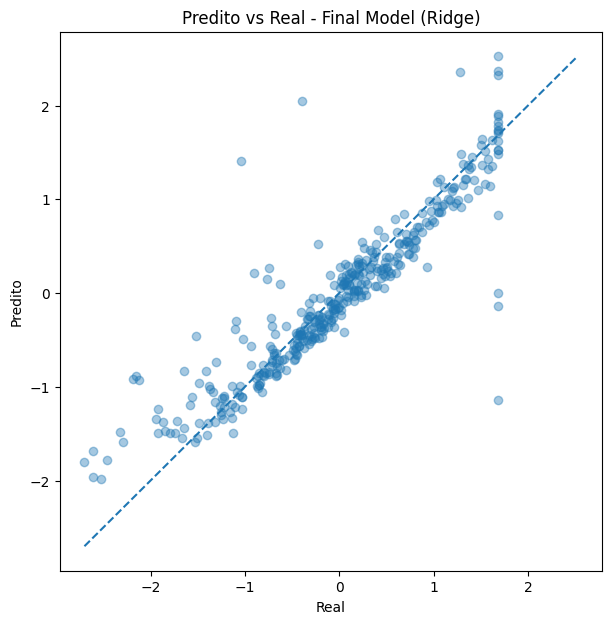

In [10]:

# %%
# (10) Gráficos: Predito vs Real e Resíduos
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred_final, alpha=0.4)
lims = [min(y_test.min(), y_pred_final.min()), max(y_test.max(), y_pred_final.max())]
plt.plot(lims, lims, '--')
plt.xlabel('Real')
plt.ylabel('Predito')
plt.title('Predito vs Real - Final Model (Ridge)')
plt.show()

Text(0.5, 1.0, 'Histograma dos Resíduos')

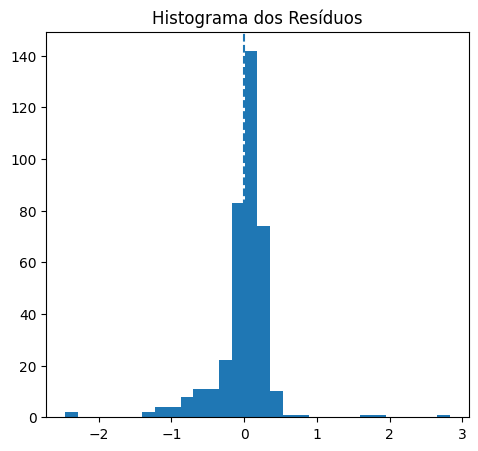

In [11]:
residuals = y_test - y_pred_final
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(residuals, bins=30)
plt.axvline(0, linestyle='--')
plt.title('Histograma dos Resíduos')

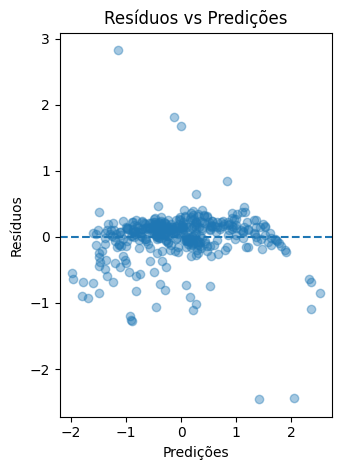

In [12]:
plt.subplot(1,2,2)
plt.scatter(y_pred_final, residuals, alpha=0.4)
plt.axhline(0, linestyle='--')
plt.xlabel('Predições')
plt.ylabel('Resíduos')
plt.title('Resíduos vs Predições')
plt.tight_layout()
plt.show()

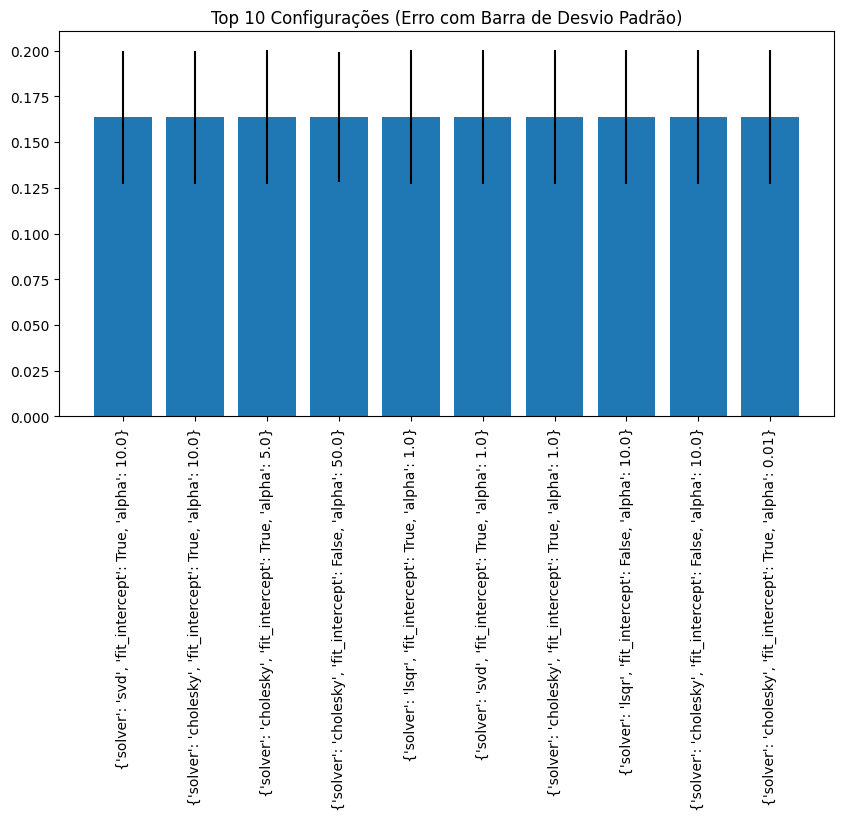

In [13]:
plt.figure(figsize=(10,5))
top10 = cv_df.sort_values("mean_test_score", ascending=False).head(10)
plt.bar(range(10), -top10["mean_test_score"], yerr=top10["std_test_score"])
plt.xticks(range(10), [str(p) for p in top10["params"]], rotation=90)
plt.title("Top 10 Configurações (Erro com Barra de Desvio Padrão)")
plt.show()


In [16]:

# %%
# (11) Casos extremos — top 10 maiores erros absolutos
err_df = pd.DataFrame({'real': y_test, 'pred': y_pred_final})
err_df['abs_error'] = (err_df['real'] - err_df['pred']).abs()
top_err = err_df.sort_values('abs_error', ascending=False).head(10)
display(top_err)


,real,pred,abs_error
1545,1.681143,-1.143246,2.824389
621,-1.043959,1.413460,2.457420
2345,-0.398840,2.045304,2.444144
1873,1.681143,-0.133097,1.814240
2019,1.681143,-0.003681,1.684825
208,-2.157622,-0.887181,1.270441
620,-2.181118,-0.916338,1.264779
1325,-2.122663,-0.924208,1.198456
1898,-0.901144,0.210535,1.111678
1231,1.274734,2.361186,1.086452


In [15]:

# %%
# (12) Salvar modelo final
os.makedirs('models', exist_ok=True)
joblib.dump(final_model, 'models/modelo_final.joblib')
print('Modelo salvo em models/modelo_final.joblib')


Modelo salvo em models/modelo_final.joblib



## Conclusões e próximos passos

- O modelo base usado na Etapa 3 foi **LinearRegression**; aqui otimizamos **Ridge** (regularização L2) para obter hiperparâmetros relevantes.
- Mostramos as métricas antes (baseline) e depois (modelo final) e plotamos resíduos + predito vs real.

### Próximos passos recomendados:
- Testar Lasso / ElasticNet / XGBoost / LightGBM para comparação.
- Fazer feature importance / permutation importance para entender variáveis mais relevantes.
- Se houver ordem temporal, usar validação temporal (TimeSeriesSplit) em vez de KFold.
